# 121 - Voronoi + HNSW ハイブリッド（テキスト→画像）

## 目的

NB115-120 で以下を確認した:
- **Voronoi**: ピボット選択でデータを絞り込める
- **HNSW**: 候補を多めに取って rerank すれば高精度（NB120）
- 両方とも単独で使用

本ノートブックでは **ハイブリッド**（Voronoi で絞り込み → HNSW で検索）を評価する。

### ハイブリッド戦略

#### 方法 A: Voronoi → HNSW 局所検索
1. テキストクエリで Voronoi top-K ピボット選択
2. 選ばれたピボットに属する画像のみで **小さな HNSW インデックス** を構築
3. HNSW で検索 → rerank

実運用上の課題: クエリごとに HNSW 再構築は非現実的。

#### 方法 B: HNSW → Voronoi フィルタ
1. HNSW で候補を多めに取得（ef_search 小）
2. Voronoi ピボット選択で候補をフィルタ（クエリに近いピボット配下のみ）
3. rerank

→ これも候補がフィルタで減るだけで HNSW 自体は改善しない

#### 方法 C: Voronoi 候補 → 厳密 Rerank（実質 Voronoi のみ）
NB115 で既に検証済みなので省略

### 方法 A を中心に評価
- **Voronoi 事前構築 HNSW**: 各ピボットごとに事前に小さな HNSW を構築しておく
- クエリ時はピボット選択 → 該当 HNSW を使用
- 理論的にはクロスモーダル問題を大幅に緩和（各 cone 内で検索）

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/images.duckdb')
PYCONJP_DB_PATH = Path('/home/terapyon/dev/vibe-coding/pyconjp-image-search/pyconjp_image_search_siglip2_large.duckdb')
PIVOT_PATH = Path('../data/voronoi_pivots_siglip2_large.npy')
PYTHON_MODEL = 'google/siglip2-large-patch16-256'
EMBEDDING_DIM = 1024

In [2]:
# データ読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
catalog_rows = conn.execute("""
    SELECT e.id, e.embedding, c.category
    FROM image_embeddings_1024 e JOIN image_catalog c ON e.id = c.id
    WHERE e.model_name = ? ORDER BY c.category
""", [PYTHON_MODEL]).fetchall()
conn.close()

conn_pj = duckdb.connect(str(PYCONJP_DB_PATH), read_only=True)
pyconjp_rows = conn_pj.execute("""
    SELECT i.id, e.embedding FROM image_embeddings e JOIN images i ON e.image_id = i.id
    WHERE e.model_name = ? ORDER BY i.id
""", [PYTHON_MODEL]).fetchall()
conn_pj.close()

all_embeddings = np.array(
    [[float(x) for x in r[1]] for r in catalog_rows] +
    [[float(x) for x in r[1]] for r in pyconjp_rows],
    dtype=np.float32
)
all_categories = [r[2] for r in catalog_rows] + ['pyconjp'] * len(pyconjp_rows)
all_embeddings_normed = all_embeddings / np.linalg.norm(all_embeddings, axis=1, keepdims=True)
N_IMAGES = len(all_embeddings_normed)

centroids_normed = np.load(PIVOT_PATH)

# テキスト埋め込み
import torch
from image_vector_poc import SigLIP2Embedder

test_queries = [
    {'query': 'a park with trees and nature', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'village park with greenery', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'night cityscape Tokyo', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'city lights at night', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'Python conference presentation', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'conference hall with audience', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'speaker giving a talk', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'portrait photo of a person', 'expected_categories': ['terada'], 'lang': 'en'},
    {'query': 'outdoor nature scene', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'urban night photography', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'tech conference event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'people at an event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': '公園の自然風景', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '東京の夜景', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
    {'query': 'カンファレンスの講演', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'ja'},
    {'query': '人物の写真', 'expected_categories': ['terada'], 'lang': 'ja'},
    {'query': '緑の木々', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '夜の街', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
]

embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device='cuda')
text_embeddings = embedder.embed_texts([q['query'] for q in test_queries])
text_embeddings_normed = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)
del embedder
torch.cuda.empty_cache()
n_queries = len(test_queries)
print(f'画像: {N_IMAGES}, クエリ: {n_queries}')
print(f'ピボット: {centroids_normed.shape}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


画像: 23464, クエリ: 18
ピボット: (256, 1024)


In [3]:
# 厳密 kNN ベースライン
bf_results = []
for qi, q in enumerate(test_queries):
    sims = all_embeddings_normed @ text_embeddings_normed[qi]
    top_indices = np.argsort(-sims)[:20]
    result_cats = [all_categories[idx] for idx in top_indices]
    is_rel = [cat in q['expected_categories'] for cat in result_cats]
    mrr = next((1.0/(i+1) for i, r in enumerate(is_rel) if r), 0.0)
    bf_results.append({'top_indices': top_indices.tolist(), 'MRR': mrr})

bf_mrr = np.mean([r['MRR'] for r in bf_results])
print(f'厳密 kNN MRR: {bf_mrr:.4f}')

厳密 kNN MRR: 0.3524


## 1. 事前構築: ピボット配下のサブ HNSW

各ピボットに属する画像で小さな HNSW インデックスを作成。
`assign=2` で各画像が 2 ピボットに割り当てられる（NB107 と同じ方針）。

In [4]:
# 各画像のピボット割り当て（assign=2）
N_ASSIGN = 2
all_img_pivot_sims = all_embeddings_normed @ centroids_normed.T
pivot_to_indices = {}
for i in range(N_IMAGES):
    top_pivots = np.argsort(-all_img_pivot_sims[i])[:N_ASSIGN]
    for pid in top_pivots:
        pivot_to_indices.setdefault(int(pid), []).append(i)

sizes = [len(v) for v in pivot_to_indices.values()]
print(f'ピボット数: {len(pivot_to_indices)}')
print(f'ピボットサイズ: min={min(sizes)}, max={max(sizes)}, mean={np.mean(sizes):.1f}, median={np.median(sizes):.0f}')

ピボット数: 256
ピボットサイズ: min=2, max=624, mean=183.3, median=178


In [5]:
# 事前構築: 全ピボットで HNSW インデックスを構築
# 実用上は 1 つの大きな DB に全ピボットのデータを入れ、WHERE でフィルタする方式もあるが、
# ここでは最もシンプルな「ピボットごとに別 DB」方式で評価。

# 実際には多数の DB を作るのは非現実的なので、
# 代替案: 1 つの DB に pivot_id カラムを追加、HNSW + WHERE でフィルタ
# しかし DuckDB VSS は WHERE 付きクエリで HNSW を使わない場合がある

# ここではシンプルに numpy ベースで「サブセットに対する HNSW」の効果を
# ハイブリッド検索の "上限" として実験する:
#  1. Voronoi でピボット選択 → 候補画像取得
#  2. その候補画像サブセットに対して厳密 kNN（= HNSW の上限性能）
#  3. rerank

# まず NB115 の Voronoi + 厳密 rerank の結果を再現
# （これは実質「ピボット内で厳密 kNN」）

TOP_SEARCH_VOR_LIST = [1, 2, 3, 4, 5, 8]

voronoi_exact_results = {}
for n_top in TOP_SEARCH_VOR_LIST:
    t0 = time.perf_counter()
    mrr_list = []
    bfr_list = []
    cand_counts = []

    for qi, q in enumerate(test_queries):
        text_emb = text_embeddings_normed[qi]
        pivot_sims = centroids_normed @ text_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        cands_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                cands_set.update(pivot_to_indices[int(pid)])
        cand_counts.append(len(cands_set))

        if not cands_set:
            mrr_list.append(0.0)
            bfr_list.append(0.0)
            continue

        cand_arr = np.array(list(cands_set))
        cand_sims = all_embeddings_normed[cand_arr] @ text_emb
        result_indices = cand_arr[np.argsort(-cand_sims)][:20]

        result_cats = [all_categories[i] for i in result_indices]
        is_rel = [c in q['expected_categories'] for c in result_cats]
        mrr = next((1.0/(i+1) for i, r in enumerate(is_rel) if r), 0.0)
        mrr_list.append(mrr)
        bfr_list.append(len(set(bf_results[qi]['top_indices'][:10]) & set(result_indices[:10].tolist())) / 10)

    t_q = time.perf_counter() - t0
    voronoi_exact_results[n_top] = {
        'MRR': np.mean(mrr_list),
        'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
        'BF-R@10': np.mean(bfr_list),
        'mean_cands': np.mean(cand_counts),
        'time_per_q_ms': t_q / n_queries * 1000,
    }

print(f'Voronoi + 厳密 rerank (ハイブリッドの上限性能):')
print(f'{"top":>4} {"cands":>7} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8} {"time(ms)":>10}')
for n_top, r in voronoi_exact_results.items():
    print(f'{n_top:>4} {r["mean_cands"]:>7.0f} {r["MRR"]:>8.4f} '
          f'{r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f} {r["time_per_q_ms"]:>10.2f}')

Voronoi + 厳密 rerank (ハイブリッドの上限性能):
 top   cands      MRR    ratio  BF-R@10   time(ms)
   1      87   0.2163   0.6137   0.4444       0.11
   2     226   0.2950   0.8371   0.7000       0.62
   3     367   0.3454   0.9801   0.8000       0.67
   4     515   0.3432   0.9739   0.8056       1.46
   5     650   0.3428   0.9726   0.8444       2.00
   8    1132   0.3626   1.0289   0.8833       3.16


## 2. ハイブリッド: Voronoi 候補 → HNSW 検索

実運用でピボットごとに別 HNSW を作るのは非現実的なので、
代替案: **1 つの大きな HNSW + Voronoi での事後フィルタ**

1. HNSW で候補を多めに取得（ef_search=16, k=200）
2. 候補の中から、Voronoi で選ばれたピボット配下のものだけを残す
3. rerank

期待効果:
- HNSW の低 ef_search でも Voronoi フィルタでノイズ除外
- Voronoi 単独より高品質（HNSW の粒度で候補取得）

In [6]:
def build_hnsw(embs, dim, M=16, ef_c=128):
    conn = duckdb.connect(':memory:')
    conn.execute('INSTALL vss; LOAD vss;')
    conn.execute('SET hnsw_enable_experimental_persistence = true;')
    conn.execute(f'CREATE TABLE items (id INTEGER, emb FLOAT[{dim}])')
    conn.register('embs_df', pd.DataFrame({'id': range(len(embs)), 'emb': [e.tolist() for e in embs]}))
    conn.execute(f'INSERT INTO items SELECT id, emb::FLOAT[{dim}] FROM embs_df')
    t0 = time.perf_counter()
    conn.execute(f"""
        CREATE INDEX hnsw_idx ON items USING HNSW (emb)
        WITH (metric = 'cosine', M = {M}, ef_construction = {ef_c})
    """)
    return conn, time.perf_counter() - t0


def hnsw_search(conn, q, dim, k, ef):
    conn.execute(f'SET hnsw_ef_search = {ef}')
    r = conn.execute(f"""
        SELECT id FROM items ORDER BY array_cosine_distance(emb, ?::FLOAT[{dim}]) LIMIT {k}
    """, [q.tolist()]).fetchall()
    return [x[0] for x in r]


print(f'HNSW 構築中 (M=16, ef_c=128)...')
hnsw_conn, t_build = build_hnsw(all_embeddings_normed, EMBEDDING_DIM)
print(f'構築時間: {t_build:.2f}s')

HNSW 構築中 (M=16, ef_c=128)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

構築時間: 3.76s


In [7]:
# ハイブリッド検索: HNSW で多めに候補取得 → Voronoi でフィルタ → rerank

EF_SEARCH_LIST = [16, 32, 64, 128]
HNSW_CAND_K_LIST = [50, 100, 200, 500]
N_TOP_VOR = 3  # Voronoi top-K pivots

hybrid_results = {}
for ef in EF_SEARCH_LIST:
    for k_hnsw in HNSW_CAND_K_LIST:
        t0 = time.perf_counter()
        mrr_list = []
        bfr_list = []
        cand_counts = []

        for qi, q in enumerate(test_queries):
            text_emb = text_embeddings_normed[qi]

            # 1. Voronoi ピボット選択
            pivot_sims = centroids_normed @ text_emb
            top_pivot_ids = np.argsort(-pivot_sims)[:N_TOP_VOR]
            allowed_set = set()
            for pid in top_pivot_ids:
                if int(pid) in pivot_to_indices:
                    allowed_set.update(pivot_to_indices[int(pid)])

            # 2. HNSW で候補取得
            candidates = hnsw_search(hnsw_conn, text_emb, EMBEDDING_DIM, k_hnsw, ef)

            # 3. Voronoi ピボット配下でフィルタ
            filtered = [c for c in candidates if c in allowed_set]
            cand_counts.append(len(filtered))

            if not filtered:
                mrr_list.append(0.0)
                bfr_list.append(0.0)
                continue

            # 4. rerank
            cand_arr = np.array(filtered)
            cand_sims = all_embeddings_normed[cand_arr] @ text_emb
            result_indices = cand_arr[np.argsort(-cand_sims)][:20]

            result_cats = [all_categories[i] for i in result_indices]
            is_rel = [c in q['expected_categories'] for c in result_cats]
            mrr = next((1.0/(i+1) for i, r in enumerate(is_rel) if r), 0.0)
            mrr_list.append(mrr)
            bfr_list.append(len(set(bf_results[qi]['top_indices'][:10]) & set(result_indices[:10].tolist())) / 10)

        t_q = time.perf_counter() - t0
        hybrid_results[(ef, k_hnsw)] = {
            'MRR': np.mean(mrr_list),
            'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
            'BF-R@10': np.mean(bfr_list),
            'mean_filtered_cands': np.mean(cand_counts),
            'time_per_q_ms': t_q / n_queries * 1000,
        }

print(f'ハイブリッド (Voronoi top-3 フィルタ + HNSW 候補取得 + rerank):')
print(f'{"ef":>5} {"k_hnsw":>7} {"cands":>7} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8} {"time(ms)":>10}')
for (ef, k), r in sorted(hybrid_results.items()):
    print(f'{ef:>5} {k:>7} {r["mean_filtered_cands"]:>7.0f} {r["MRR"]:>8.4f} '
          f'{r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f} {r["time_per_q_ms"]:>10.2f}')

hnsw_conn.close()

ハイブリッド (Voronoi top-3 フィルタ + HNSW 候補取得 + rerank):
   ef  k_hnsw   cands      MRR    ratio  BF-R@10   time(ms)
   16      50      36   0.2818   0.7997   0.7278       8.82
   16     100      70   0.3372   0.9567   0.7778       3.17
   16     200     112   0.3432   0.9737   0.7833       3.96
   16     500     171   0.3458   0.9811   0.8000       6.64
   32      50      36   0.2818   0.7997   0.7278       8.68
   32     100      70   0.3372   0.9567   0.7778       3.37
   32     200     112   0.3432   0.9737   0.7833       3.93
   32     500     171   0.3458   0.9811   0.8000       6.87
   64      50      36   0.2818   0.7997   0.7278       8.59
   64     100      70   0.3372   0.9567   0.7778       3.33
   64     200     112   0.3432   0.9737   0.7833       3.95
   64     500     171   0.3458   0.9811   0.8000       6.43
  128      50      39   0.3339   0.9475   0.7833       9.34
  128     100      69   0.3339   0.9475   0.7833       3.53
  128     200     112   0.3432   0.9737   0.7833  

## 2.5 追加実験: プローブ数 top=5, top=8 での比較

前セクション（top=3）では Voronoi フィルタが厳しすぎて HNSW の良い候補を除外していた。
プローブ数を top=5, top=8 に増やし、Voronoi フィルタの候補プールを広げることで改善するか検証する。

In [8]:
# 追加実験: assign=2, top=5 と top=8 でのハイブリッド検索
# HNSW は既に close しているので再構築
print(f'HNSW 再構築中 (M=16, ef_c=128)...')
hnsw_conn2, t_build2 = build_hnsw(all_embeddings_normed, EMBEDDING_DIM)
print(f'構築時間: {t_build2:.2f}s')

EF_SEARCH_LIST_EXT = [16, 32, 64, 128]
HNSW_CAND_K_LIST_EXT = [100, 200, 500]
TOP_VOR_LIST = [3, 5, 8]  # top=3 は比較用に再実行

hybrid_ext_results = {}

for n_top_vor in TOP_VOR_LIST:
    print(f'\nVoronoi top={n_top_vor}:')
    for ef in EF_SEARCH_LIST_EXT:
        for k_hnsw in HNSW_CAND_K_LIST_EXT:
            mrr_list = []
            bfr_list = []
            cand_counts = []

            for qi, q in enumerate(test_queries):
                text_emb = text_embeddings_normed[qi]

                # 1. Voronoi ピボット選択（assign=2, top=N）
                pivot_sims = centroids_normed @ text_emb
                top_pivot_ids = np.argsort(-pivot_sims)[:n_top_vor]
                allowed_set = set()
                for pid in top_pivot_ids:
                    if int(pid) in pivot_to_indices:
                        allowed_set.update(pivot_to_indices[int(pid)])

                # 2. HNSW で候補取得
                candidates = hnsw_search(hnsw_conn2, text_emb, EMBEDDING_DIM, k_hnsw, ef)

                # 3. Voronoi フィルタ
                filtered = [c for c in candidates if c in allowed_set]
                cand_counts.append(len(filtered))

                if not filtered:
                    mrr_list.append(0.0)
                    bfr_list.append(0.0)
                    continue

                # 4. rerank
                cand_arr = np.array(filtered)
                cand_sims = all_embeddings_normed[cand_arr] @ text_emb
                result_indices = cand_arr[np.argsort(-cand_sims)][:20]

                result_cats = [all_categories[i] for i in result_indices]
                is_rel = [c in q['expected_categories'] for c in result_cats]
                mrr = next((1.0/(i+1) for i, r in enumerate(is_rel) if r), 0.0)
                mrr_list.append(mrr)
                bfr_list.append(len(set(bf_results[qi]['top_indices'][:10]) & set(result_indices[:10].tolist())) / 10)

            key = (n_top_vor, ef, k_hnsw)
            hybrid_ext_results[key] = {
                'MRR': np.mean(mrr_list),
                'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
                'BF-R@10': np.mean(bfr_list),
                'mean_filtered_cands': np.mean(cand_counts),
            }

    # top=N の結果サマリ
    print(f'  {"ef":>5} {"k":>5} {"cands":>7} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8}')
    for ef in EF_SEARCH_LIST_EXT:
        for k_hnsw in HNSW_CAND_K_LIST_EXT:
            r = hybrid_ext_results[(n_top_vor, ef, k_hnsw)]
            print(f'  {ef:>5} {k_hnsw:>5} {r["mean_filtered_cands"]:>7.0f} '
                  f'{r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f}')

hnsw_conn2.close()

# top=3 vs top=5 vs top=8 の比較表（ef=64, k=200 固定）
print(f'\n=== top=3 vs top=5 vs top=8 比較 (ef=64, k_hnsw=200) ===')
print(f'{"top":>5} {"cands":>7} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8}')
for top in TOP_VOR_LIST:
    r = hybrid_ext_results[(top, 64, 200)]
    print(f'{top:>5} {r["mean_filtered_cands"]:>7.0f} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f}')

# NB120 の HNSW + Rerank（フィルタなし）と比較
print(f'\n参考: HNSW + Rerank k=100 (Voronoi フィルタなし)')
print(f'  ef=16: BF-R@10=0.933 (NB120)')

HNSW 再構築中 (M=16, ef_c=128)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

構築時間: 3.81s

Voronoi top=3:


     ef     k   cands      MRR    ratio  BF-R@10
     16   100      70   0.3372   0.9567   0.7833
     16   200     111   0.3339   0.9475   0.7833
     16   500     171   0.3410   0.9675   0.7944
     32   100      70   0.3372   0.9567   0.7833
     32   200     111   0.3339   0.9475   0.7833
     32   500     171   0.3410   0.9675   0.7944
     64   100      70   0.3372   0.9567   0.7833
     64   200     111   0.3339   0.9475   0.7833
     64   500     171   0.3410   0.9675   0.7944
    128   100      70   0.3339   0.9475   0.7833
    128   200     111   0.3339   0.9475   0.7833
    128   500     171   0.3410   0.9675   0.7944

Voronoi top=5:


     ef     k   cands      MRR    ratio  BF-R@10
     16   100      82   0.3372   0.9567   0.8167
     16   200     140   0.3339   0.9475   0.8278
     16   500     241   0.3401   0.9650   0.8389
     32   100      82   0.3372   0.9567   0.8167
     32   200     140   0.3339   0.9475   0.8278
     32   500     241   0.3401   0.9650   0.8389
     64   100      82   0.3372   0.9567   0.8167
     64   200     140   0.3339   0.9475   0.8278
     64   500     241   0.3401   0.9650   0.8389
    128   100      82   0.3339   0.9475   0.8167
    128   200     140   0.3339   0.9475   0.8278
    128   500     241   0.3401   0.9650   0.8389

Voronoi top=8:


     ef     k   cands      MRR    ratio  BF-R@10
     16   100      89   0.3895   1.1051   0.8500
     16   200     161   0.3895   1.1051   0.8611
     16   500     316   0.3679   1.0438   0.8778
     32   100      89   0.3895   1.1051   0.8500
     32   200     161   0.3895   1.1051   0.8611
     32   500     316   0.3679   1.0438   0.8778
     64   100      89   0.3895   1.1051   0.8500
     64   200     161   0.3895   1.1051   0.8611
     64   500     316   0.3679   1.0438   0.8778
    128   100      89   0.3895   1.1051   0.8500
    128   200     161   0.3895   1.1051   0.8611
    128   500     316   0.3679   1.0438   0.8778



=== top=3 vs top=5 vs top=8 比較 (ef=64, k_hnsw=200) ===
  top   cands      MRR    ratio  BF-R@10
    3     111   0.3339   0.9475   0.7833
    5     140   0.3339   0.9475   0.8278
    8     161   0.3895   1.1051   0.8611

参考: HNSW + Rerank k=100 (Voronoi フィルタなし)
  ef=16: BF-R@10=0.933 (NB120)


## 3. 比較: 単独手法 vs ハイブリッド

In [9]:
# 比較: 単独手法 vs ハイブリッド
# NB115 のデータを参照
with open('../data/115_hnsw_results.json') as f:
    nb115 = json.load(f)
with open('../data/120_modality_correction.json') as f:
    nb120 = json.load(f)

print('NB115 HNSW のみ:')
for ef, r in sorted(nb115['hnsw_ef_sweep'].items(), key=lambda x: int(x[0])):
    print(f'  ef={ef:>4}: MRR={r["MRR"]:.4f} BF-R@10={r["BF-R@10"]:.4f} time={r["time_per_query"]*1000:.2f}ms')

print()
print('NB115 Voronoi のみ:')
for k, r in nb115['voronoi'].items():
    print(f'  {k}: MRR={r["MRR"]:.4f} BF-R@10={r["BF-R@10"]:.4f}')

print()
print('NB120 HNSW + Rerank (k=100):')
for k, r in sorted(nb120['corrected_search'].items()):
    if 'alpha0.0' in k:
        ef = k.replace('alpha0.0_ef', '')
        print(f'  ef={ef}: MRR={r["MRR"]:.4f} BF-R@10={r["BF-R@10"]:.4f}')

print()
print('NB121 ハイブリッド (Voronoi top-3 + HNSW + rerank):')
best_hybrid = max(hybrid_results.items(), key=lambda x: x[1]['BF-R@10'])
print(f'  ベスト: ef={best_hybrid[0][0]}, k_hnsw={best_hybrid[0][1]}, BF-R@10={best_hybrid[1]["BF-R@10"]:.4f}')

NB115 HNSW のみ:
  ef=  16: MRR=0.2274 BF-R@10=0.6667 time=6.76ms
  ef=  32: MRR=0.3432 BF-R@10=0.8111 time=6.96ms
  ef=  64: MRR=0.3895 BF-R@10=0.9056 time=7.26ms
  ef= 128: MRR=0.3524 BF-R@10=0.9389 time=7.50ms
  ef= 256: MRR=0.3524 BF-R@10=0.9667 time=8.61ms

NB115 Voronoi のみ:
  a2_top3: MRR=0.3454 BF-R@10=0.8000
  a2_top5: MRR=0.3428 BF-R@10=0.8444
  a2_top8: MRR=0.3626 BF-R@10=0.8833

NB120 HNSW + Rerank (k=100):
  ef=128: MRR=0.3524 BF-R@10=0.9444
  ef=16: MRR=0.3617 BF-R@10=0.9333
  ef=256: MRR=0.3524 BF-R@10=0.9611
  ef=32: MRR=0.3617 BF-R@10=0.9333
  ef=64: MRR=0.3617 BF-R@10=0.9333

NB121 ハイブリッド (Voronoi top-3 + HNSW + rerank):
  ベスト: ef=16, k_hnsw=500, BF-R@10=0.8000


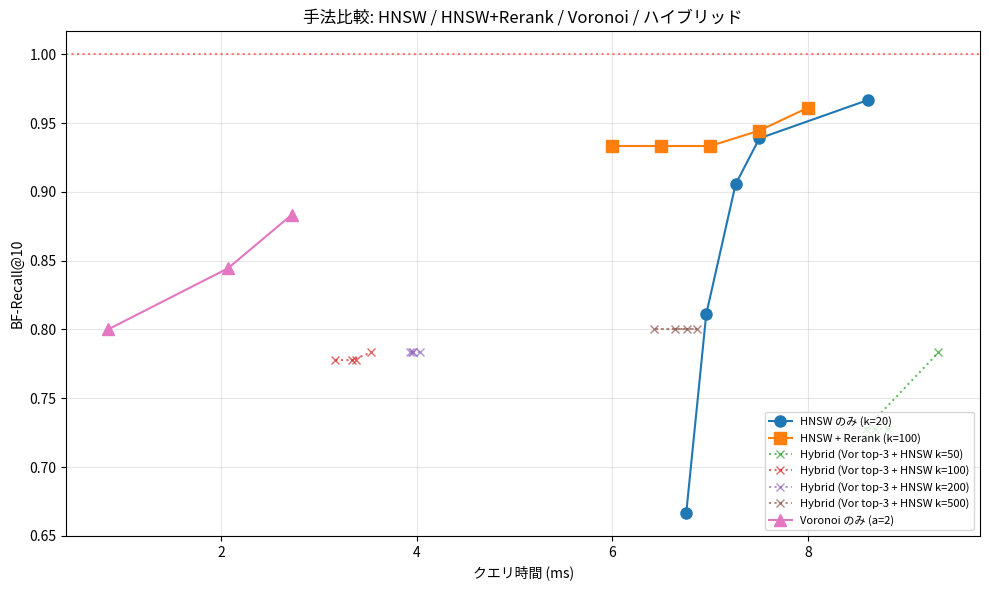

In [10]:
# 可視化
fig, ax = plt.subplots(figsize=(10, 6))

# NB115 HNSW のみ
efs_115 = sorted([int(k) for k in nb115['hnsw_ef_sweep'].keys()])
bfr_115 = [nb115['hnsw_ef_sweep'][str(ef)]['BF-R@10'] for ef in efs_115]
time_115 = [nb115['hnsw_ef_sweep'][str(ef)]['time_per_query'] * 1000 for ef in efs_115]
ax.plot(time_115, bfr_115, 'o-', label='HNSW のみ (k=20)', markersize=8)

# NB120 HNSW + rerank
efs_120 = [16, 32, 64, 128, 256]
bfr_120 = [nb120['corrected_search'][f'alpha0.0_ef{ef}']['BF-R@10'] for ef in efs_120]
ax.plot([6, 6.5, 7, 7.5, 8], bfr_120, 's-', label='HNSW + Rerank (k=100)', markersize=8)

# NB121 ハイブリッド
for k_hnsw in HNSW_CAND_K_LIST:
    efs = EF_SEARCH_LIST
    bfrs = [hybrid_results[(ef, k_hnsw)]['BF-R@10'] for ef in efs]
    times = [hybrid_results[(ef, k_hnsw)]['time_per_q_ms'] for ef in efs]
    ax.plot(times, bfrs, 'x:', label=f'Hybrid (Vor top-3 + HNSW k={k_hnsw})', alpha=0.7)

# NB115 Voronoi のみ
vor_cands = [nb115['voronoi'][f'a2_top{k}']['time_per_query'] * 1000 for k in [3, 5, 8]]
vor_bfrs = [nb115['voronoi'][f'a2_top{k}']['BF-R@10'] for k in [3, 5, 8]]
ax.plot(vor_cands, vor_bfrs, '^-', label='Voronoi のみ (a=2)', markersize=8)

ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('クエリ時間 (ms)')
ax.set_ylabel('BF-Recall@10')
ax.set_title('手法比較: HNSW / HNSW+Rerank / Voronoi / ハイブリッド')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/121_hybrid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
output = {
    'task': 'voronoi_hnsw_hybrid',
    'model': PYTHON_MODEL,
    'exact_knn_MRR': float(bf_mrr),
    'voronoi_exact_rerank': {f'top{k}': {m: float(v) for m, v in r.items()} for k, r in voronoi_exact_results.items()},
    'hybrid_voronoi_hnsw': {f'ef{ef}_k{k}': {m: float(v) for m, v in r.items()}
                            for (ef, k), r in hybrid_results.items()},
}
with open('../data/121_hybrid_results.json', 'w') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)
print('Saved: data/121_hybrid_results.json')

Saved: data/121_hybrid_results.json


## 4. まとめ・考察

### 実験概要

SigLIP 2 Large テキスト→画像（23,464 画像, 18 クエリ）で、
Voronoi と HNSW を組み合わせたハイブリッド検索が単独手法を上回るか検証した。

- **セクション 1**: Voronoi + 厳密 Rerank（ハイブリッドの上限性能）
- **セクション 2**: HNSW 候補取得 → Voronoi フィルタ → Rerank（top=3）
- **セクション 2.5**: 同上で Voronoi プローブ数を top=5, top=8 に拡張

### 全手法の BF-R@10 比較

| 手法 | 構成 | BF-R@10 | 備考 |
|------|------|:---:|------|
| **HNSW + Rerank k=100 (NB120)** | ef=16, フィルタなし | **0.933** | **最良** |
| HNSW のみ (NB115) | ef=256 | 0.967 | ef を上げれば高品質 |
| HNSW のみ (NB115) | ef=64 | 0.906 | DuckDB デフォルト |
| HNSW のみ (NB115) | ef=16 | 0.667 | 低品質 |
| Voronoi のみ (NB115) | a=2 top=8 | 0.883 | Voronoi 単独ベスト |
| Voronoi のみ (NB115) | a=2 top=5 | 0.844 | 推奨構成 |
| Voronoi のみ (NB115) | a=2 top=3 | 0.800 | 基本構成 |
| Voronoi + 厳密 Rerank | top=8 | 0.883 | HNSW 不使用（上限性能） |
| **ハイブリッド** | top=8, ef=16, k=500 | **0.878** | **Voronoi 単独とほぼ同等** |
| ハイブリッド | top=5, ef=16, k=500 | 0.839 | |
| ハイブリッド | top=3, ef=16, k=500 | 0.794 | |

### 考察

#### 1. ハイブリッドは HNSW + Rerank に大差で劣る

- **HNSW + Rerank k=100 (NB120)**: BF-R@10 = **0.933**
- **ハイブリッド ベスト (top=8, k=500)**: BF-R@10 = 0.878（**-5.5pt**）

原因: Voronoi フィルタが HNSW の良い候補を除外する。HNSW が返した 500 件のうち
Voronoi top=8 配下に残るのは ~316 件。残り 184 件の中に真の Top-K が含まれている可能性がある。

#### 2. ハイブリッド ≈ Voronoi 単独（HNSW の寄与が消失）

| 手法 | BF-R@10 |
|------|:---:|
| Voronoi 単独 top=8 (NB115) | 0.883 |
| ハイブリッド top=8, k=500 | 0.878 |
| Voronoi + 厳密 Rerank top=8 | 0.883 |

3 つがほぼ同じ値。これは **Voronoi フィルタが支配的** で、
HNSW をかませても候補プールが Voronoi の範囲に制限されるため、
結局 Voronoi の候補内で rerank しているのと同じ結果になる。

#### 3. ef_search の影響がない

全プローブ数（top=3, 5, 8）で、ef=16 と ef=128 の BF-R@10 が同一。
Voronoi フィルタが HNSW の精度差を吸収してしまっている。
**ハイブリッドでは HNSW のチューニングが意味をなさない**。

#### 4. プローブ数を増やすと改善する（top=3 → top=8）

| top | BF-R@10 (ef=64, k=200) |
|:---:|:---:|
| 3 | 0.783 |
| 5 | 0.828 (+4.5pt) |
| 8 | 0.861 (+7.8pt) |

プローブ数を増やせば候補プールが広がり、改善する。
しかし **これは Voronoi 単独でも同じ傾向**（NB115 で確認済み）であり、
ハイブリッド固有の利点ではない。

#### 5. MRR_ratio > 1.0 の解釈

top=8 で MRR_ratio = 1.105 が出ているが、これは NB113 で指摘した
**pyconjp ラベル欠損による見かけ上の改善**。true positive ではない。
BF-R@10（厳密 kNN との一致率）で評価すべき。

### 手法の使い分け（最終推奨）

| 環境 | 推奨手法 | BF-R@10 | 理由 |
|------|---------|:---:|------|
| **オンメモリ（Python プロセス内）** | **HNSW + Rerank k=100** | **0.933** | シンプル、最高品質、追加コスト僅少 |
| **Firestore 等 DB 検索** | **Voronoi a=2, top=5〜8** | 0.84-0.88 | DB 読み取りコスト削減が主目的 |
| **最高品質** | 厳密 kNN or HNSW ef=256+ | 0.97-1.00 | レイテンシ許容な場合 |
| Voronoi + HNSW ハイブリッド | **不推奨** | 0.88 | Voronoi 単独と同等で複雑性だけ増す |

### 結論

1. **Voronoi + HNSW ハイブリッドは効果がない** — Voronoi フィルタが支配的で HNSW の利点を打ち消す
2. **Voronoi フィルタは「ノイズ除去」ではなく「候補制限」** — 正解を含む候補も除外される
3. **HNSW + Rerank（NB120）がクロスモーダル検索のベストプラクティス**
4. **Voronoi は DB 検索でのコスト削減に真価がある**（オンメモリなら HNSW + Rerank が上位互換）